In [116]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict


In [117]:
class BatsmanState(TypedDict):
    
    runs: int
    balls: int
    fours: int
    sixes: int

    sr: float
    bpb: float
    boundary_percentage: float
    summary: str

In [118]:
def calculate_sr(state: BatsmanState):

    sr = (state['runs'] / state['balls']) * 100

    return {'sr': sr}

In [119]:
def calculate_bpb(state:BatsmanState):
    bpb=state['balls']/(state['fours']+state['sixes'])

   

    return {'bpb':bpb}

In [120]:
def calculate_boundary_percentage(state:BatsmanState):

    boundary_percentage=(((state['fours']*4)+(state['sixes']*6))/state['runs'])*100

   

    return {'boundary_percentage': boundary_percentage}

In [121]:
def summary(state: BatsmanState):

    summary = f"""
    strike rate - {state['sr']}  \n

    balls per boundary - {state['bpb']}   \n

    boundary percentage - {state['boundary_percentage']}   \n
    """

    return {'summary': summary}

In [122]:
graph=StateGraph(BatsmanState)

graph.add_node('calculate_sr',calculate_sr)
graph.add_node('calculate_bpb',calculate_bpb)
graph.add_node('calculate_boundary_percentage',calculate_boundary_percentage)
graph.add_node('summary',summary)

graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'calculate_bpb')
graph.add_edge(START, 'calculate_boundary_percentage')
graph.add_edge('calculate_sr', 'summary')
graph.add_edge('calculate_bpb', 'summary')
graph.add_edge('calculate_boundary_percentage', 'summary')
graph.add_edge('summary', END) 

workflow=graph.compile()

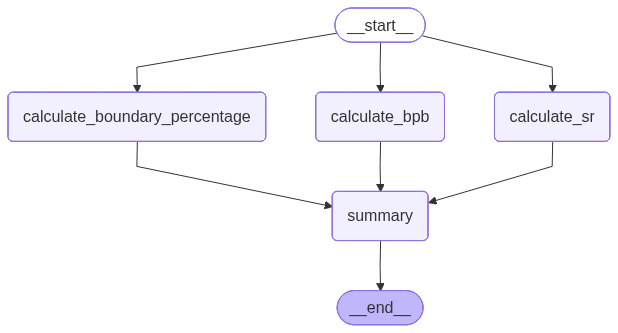

In [123]:
workflow

In [124]:
initial_state={
    'runs':100,
    'balls':50,
    'fours':6,
    'sixes':4
}
final_state=workflow.invoke(initial_state)
print(final_state)

{'runs': 100, 'balls': 50, 'fours': 6, 'sixes': 4, 'sr': 200.0, 'bpb': 5.0, 'boundary_percentage': 48.0, 'summary': '\n    strike rate - 200.0  \n\n\n    balls per boundary - 5.0   \n\n\n    boundary percentage - 48.0   \n\n    '}
